# Analyse

## Importations

In [1]:
%load_ext autoreload
%autoreload 2
from plots import *

## Entrainement et affichage DDPG

In [2]:
ddpg_config = DDPGConfig()
ddpg = run_ddpg(ddpg_config)

ddpg.visualize_best()

  0%|          | 0/30000 [00:00<?, ?it/s]

## Entrainement et affichage TD3

In [3]:
td3_config = TD3Config()
td3 = run_td3(td3_config)
td3.visualize_best()

  0%|          | 0/30000 [00:00<?, ?it/s]

## Comparaison DDPG vs TD3

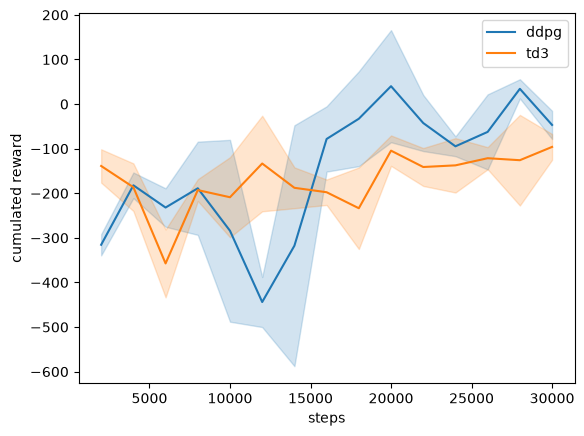

DDPG vs TD3 (final evaluation): t=3.63, p-value=0.002


In [4]:
plot_evaluations(ddpg=ddpg, td3=td3)

# The Welch t-test tells us whether the difference between the final
# evaluations is statistically significant (p-value < 0.05)
welch = stats.ttest_ind(
    ddpg.history[-1].rewards.numpy(), td3.history[-1].rewards.numpy(), equal_var=False
)
print(
    f"DDPG vs TD3 (final evaluation): t={welch.statistic:.2f}, p-value={welch.pvalue:.3f}"
)

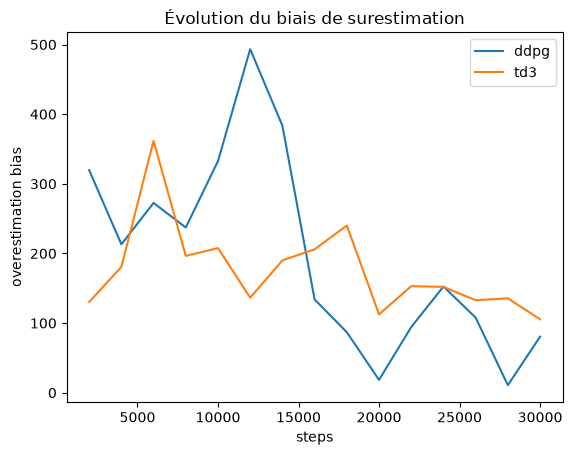

In [5]:
plot_overestimated_bias(ddpg=ddpg, td3=td3)
